# Geneva Air-Temperature Analysis

This notebook repeats the NetCDF analysis for air temperature. It imports exactly the 19 documented meteorological columns, uses `AirTC` as air temperature in degrees Celsius, and uses `AirTC_qual` as its quality flag. It computes daily mean and maximum climatologies, compares 2026, analyzes DOY 150-240, creates annual violin plots, and ranks the top 40 days.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from netCDF4 import Dataset, num2date

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "data").is_dir():
    PROJECT_DIR = PROJECT_DIR.parent
DATA_DIR = PROJECT_DIR / "data" / "léxploremeteostation_datalakesdownload (2)"
OUTPUT_DIR = PROJECT_DIR / "results"
GRAPHS_DIR = PROJECT_DIR / "graphs"
DOY_START, DOY_END = 150, 240
TEMPERATURE_THRESHOLD_C = 4.0
assert DATA_DIR.is_dir(), f"Missing NetCDF directory: {DATA_DIR}"
OUTPUT_DIR.mkdir(exist_ok=True)
GRAPHS_DIR.mkdir(exist_ok=True)

## 1. Load and Validate the 19-Column NetCDF Data

The loader selects only the documented fields, preventing extra NetCDF variables from becoming accidental DataFrame columns.

In [3]:
METEO_COLUMNS = [
    "time", "AirTC", "RH", "Slrw", "WS", "WindDir", "Rain", "BP",
    "time_qual", "Batt_qual", "Ptemp_qual", "AirTC_qual", "RH_qual",
    "Slrw_qual", "Slrm_qual", "WS_qual", "WindDir_qual", "Rain_qual", "BP_qual",
]
nc_paths = sorted(DATA_DIR.glob("*.nc"))
assert nc_paths, f"No NetCDF files found in {DATA_DIR}"

frames = []
for path in nc_paths:
    with Dataset(path) as source:
        missing = [name for name in METEO_COLUMNS if name not in source.variables]
        assert not missing, f"{path.name} is missing {missing}"
        values = {}
        time_var = source.variables["time"]
        values["time"] = num2date(time_var[:], time_var.units, only_use_cftime_datetimes=False)
        for name in METEO_COLUMNS[1:]:
            values[name] = source.variables[name][:]
        frames.append(pd.DataFrame(values))

raw = pd.concat(frames, ignore_index=True)
raw["time"] = pd.to_datetime(raw["time"], utc=True)
print("NetCDF files:", len(nc_paths))
print("DataFrame shape:", raw.shape)
print("Column count:", len(raw.columns))
assert len(raw.columns) == 19
raw.head()

NetCDF files: 371
DataFrame shape: (364157, 19)
Column count: 19


,time,AirTC,RH,Slrw,WS,WindDir,Rain,BP,time_qual,Batt_qual,Ptemp_qual,AirTC_qual,RH_qual,Slrw_qual,Slrm_qual,WS_qual,WindDir_qual,Rain_qual,BP_qual
0,2019-07-29 18:00:00+00:00,23.39,60.12,61.07,2.201,239.5,0.0,968.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2019-07-29 18:10:00+00:00,23.31,60.19,62.85,1.765,236.6,0.0,968.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2019-07-29 18:20:00+00:00,23.43,58.28,113.00,1.286,264.0,0.0,968.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2019-07-29 18:30:00+00:00,23.63,57.70,95.00,0.738,25.3,0.0,968.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2019-07-29 18:40:00+00:00,23.74,58.62,69.17,0.369,275.5,0.0,969.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Air-Temperature Feature Mapping

`AirTC` is the measured air temperature in degrees Celsius. Only observations with `AirTC_qual == 0` are used.

In [4]:
FEATURE_COLUMNS = {
    "air_temperature": "AirTC",
    "air_temperature_quality_flag": "AirTC_qual",
}
assert FEATURE_COLUMNS["air_temperature"] == "AirTC"
assert FEATURE_COLUMNS["air_temperature_quality_flag"] == "AirTC_qual"

print(raw[["AirTC", "AirTC_qual"]].dtypes)
print(raw[["AirTC", "AirTC_qual"]].isna().sum())
print(raw[["AirTC", "AirTC_qual"]].describe())
assert raw["AirTC"].notna().any()
assert set(pd.Series(raw["AirTC_qual"]).dropna().unique()).issubset({0, 1})

observations = raw[(raw["AirTC_qual"] == 0) & raw["AirTC"].notna()].copy()
observations = observations.rename(columns={"time": "timestamp", "AirTC": "air_temperature_c"})
observations = observations.drop_duplicates(subset="timestamp").sort_values("timestamp")
observations[["timestamp", "air_temperature_c"]].head()

AirTC         float64
AirTC_qual    float64
dtype: object
AirTC         0
AirTC_qual    0
dtype: int64
              AirTC     AirTC_qual
count  364157.00000  364157.000000
mean       13.02781       0.001370
std         7.13525       0.036992
min      -197.10000       0.000000
25%         7.25400       0.000000
50%        12.42000       0.000000
75%        18.81000       0.000000
max        35.96000       1.000000


,timestamp,air_temperature_c
0,2019-07-29 18:00:00+00:00,23.39
1,2019-07-29 18:10:00+00:00,23.31
2,2019-07-29 18:20:00+00:00,23.43
3,2019-07-29 18:30:00+00:00,23.63
4,2019-07-29 18:40:00+00:00,23.74


## 3. Daily Statistics and Climatology

Compute daily mean and maximum air temperature, then calculate the day-of-year climatology and overlay the available 2026 values.

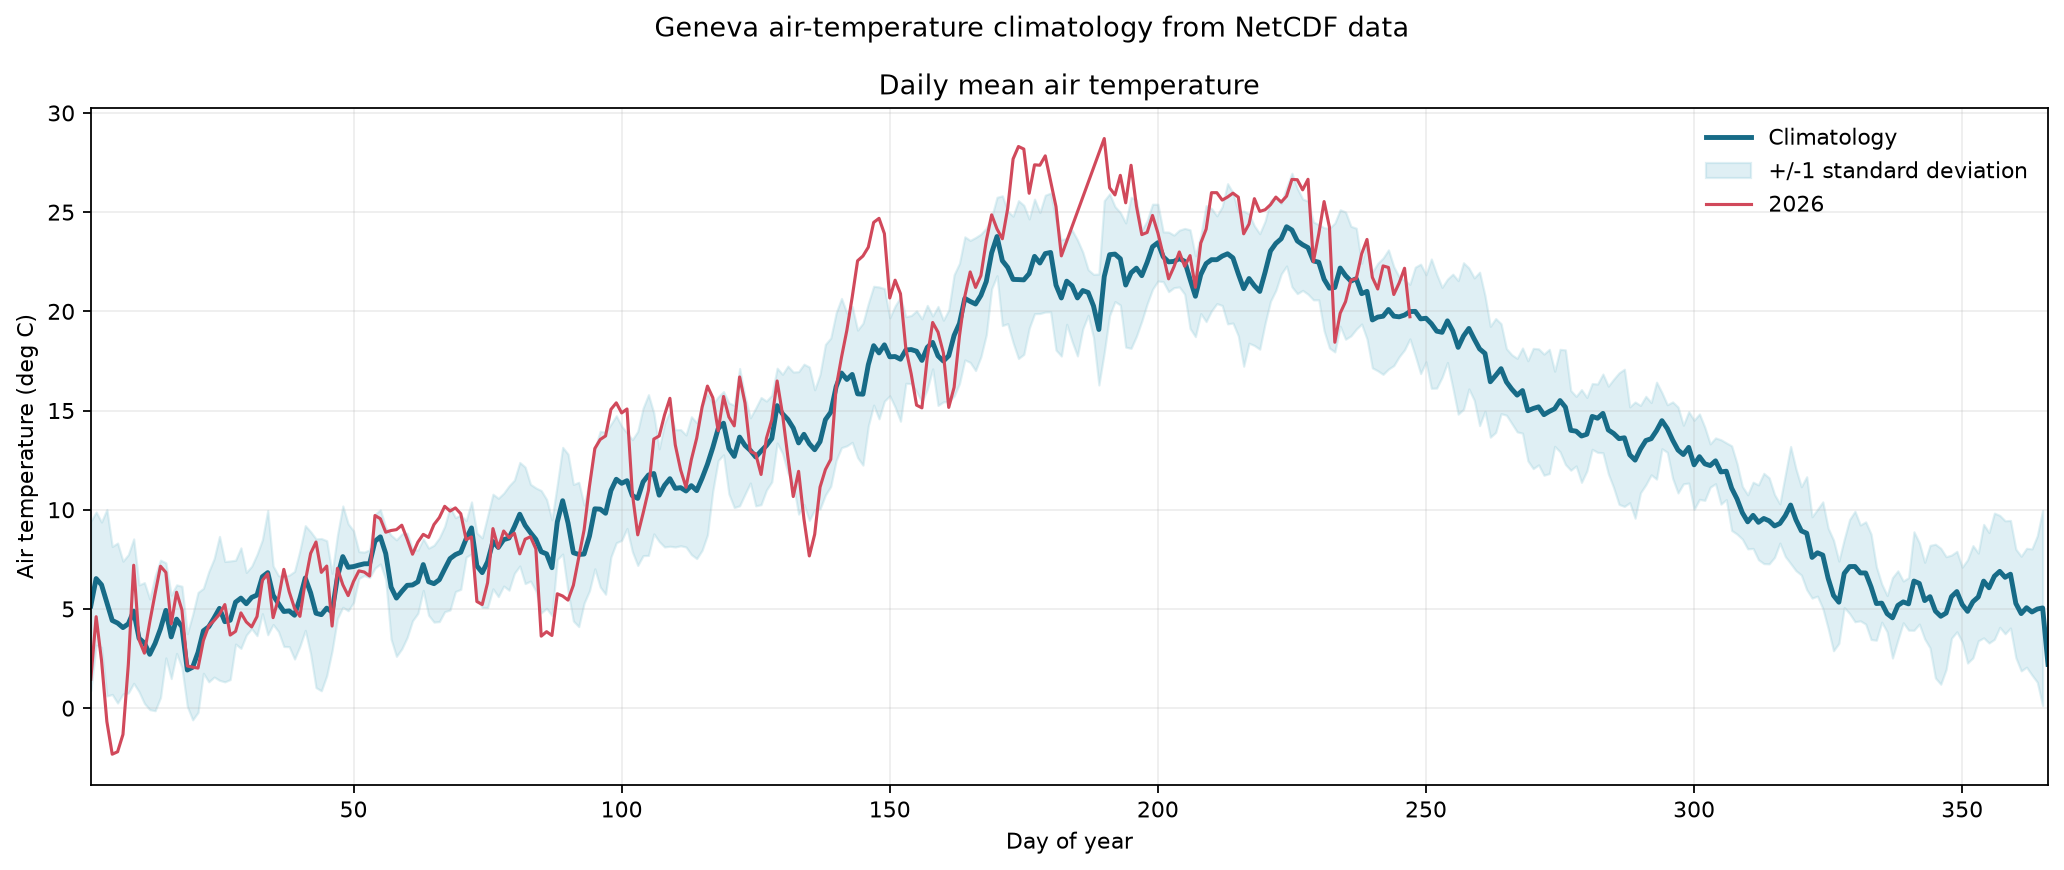

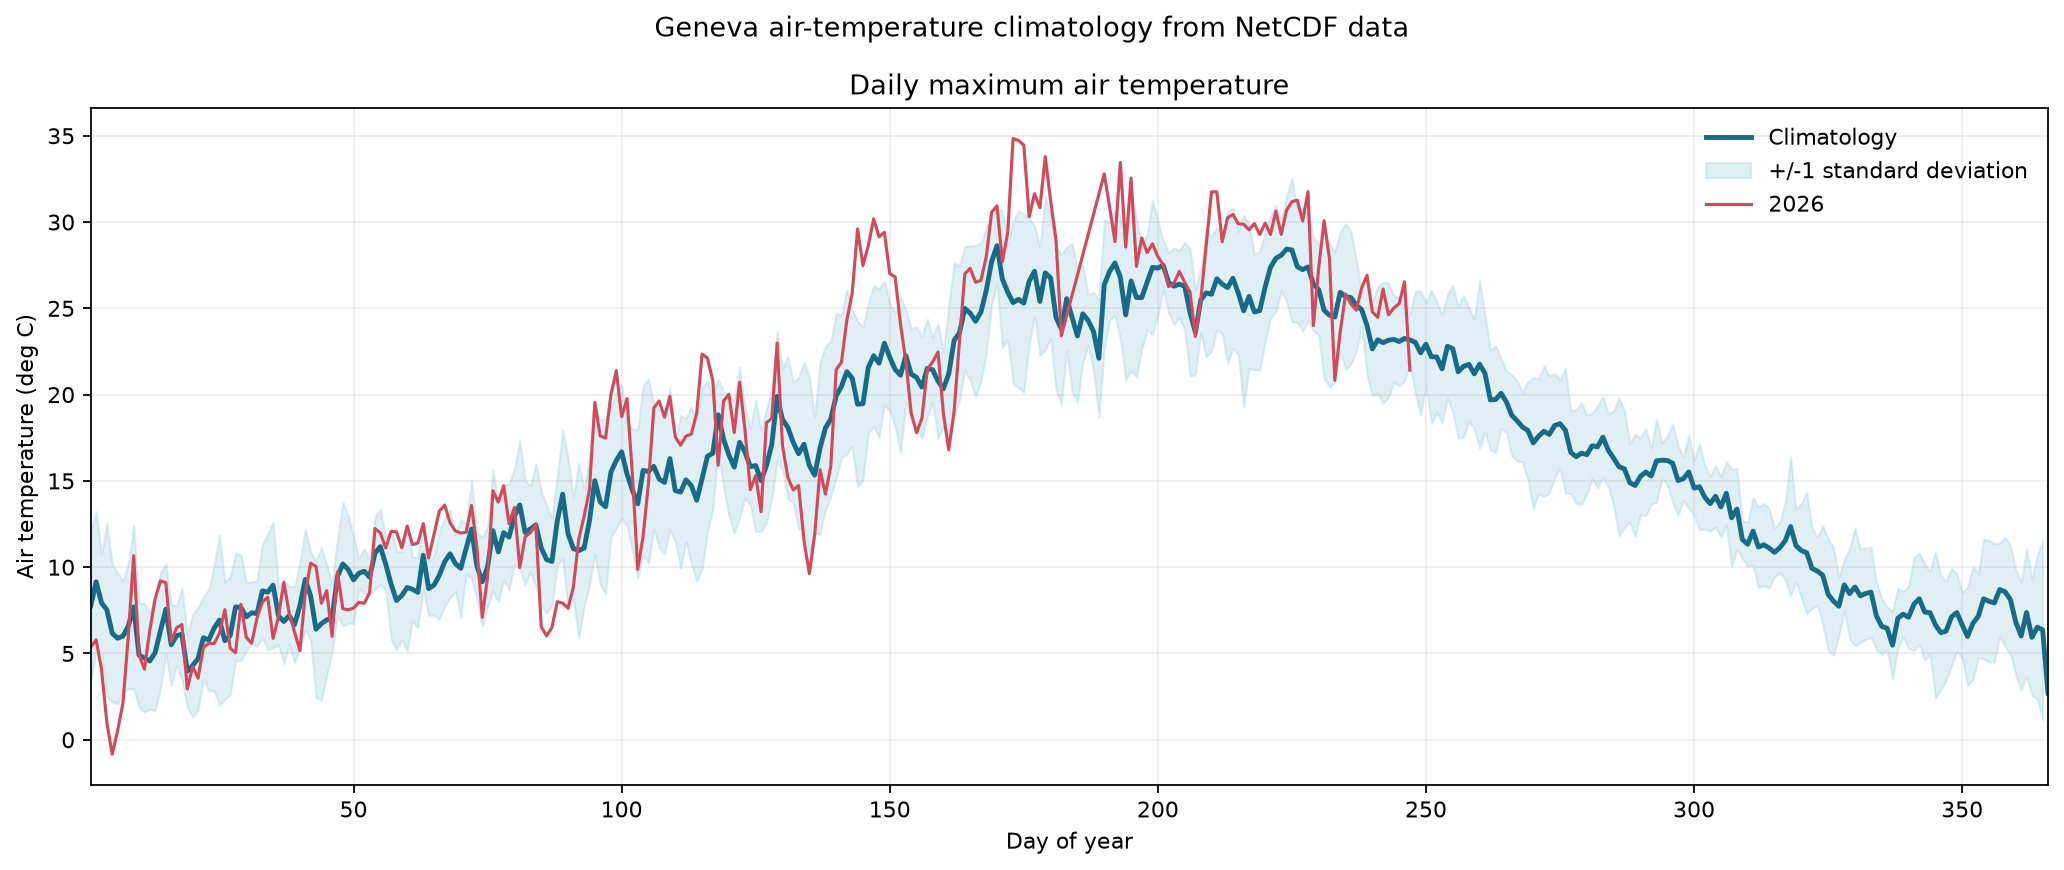

In [5]:
daily = (observations.set_index("timestamp")["air_temperature_c"].resample("D").agg(daily_mean="mean", daily_max="max", observations="count").dropna(subset=["daily_mean"]).reset_index())
daily["year"] = daily["timestamp"].dt.year
daily["day_of_year"] = daily["timestamp"].dt.dayofyear

climatology = daily.groupby("day_of_year")[["daily_mean", "daily_max"]].agg(["mean", "std"]).reset_index()
climatology.columns = ["day_of_year", "mean_air_temperature", "std_air_temperature", "mean_daily_max_air_temperature", "std_daily_max_air_temperature"]
year_2026 = daily[daily["year"] == 2026]

for mean_col, std_col, year_col, title, output_path in [
    ("mean_air_temperature", "std_air_temperature", "daily_mean", "Daily mean air temperature", GRAPHS_DIR / "geneva_air_temperature_climatology_netcdf.png"),
    ("mean_daily_max_air_temperature", "std_daily_max_air_temperature", "daily_max", "Daily maximum air temperature", GRAPHS_DIR / "geneva_air_temperature_maximum_climatology_netcdf.png"),
]:
    figure, axis = plt.subplots(figsize=(13, 5.5), dpi=160)
    axis.plot(climatology["day_of_year"], climatology[mean_col], color="#176b87", linewidth=2.2, label="Climatology")
    axis.fill_between(climatology["day_of_year"], climatology[mean_col] - climatology[std_col], climatology[mean_col] + climatology[std_col], color="#8ec9d8", alpha=0.28, label="+/-1 standard deviation")
    axis.plot(year_2026["day_of_year"], year_2026[year_col], color="#d1495b", linewidth=1.4, label="2026")
    axis.set_xlabel("Day of year")
    axis.set_ylabel("Air temperature (deg C)")
    axis.set_title(title)
    axis.set_xlim(1, 366)
    axis.grid(True, alpha=0.22)
    axis.legend(frameon=False)
    figure.suptitle("Geneva air-temperature climatology from NetCDF data")
    figure.tight_layout()
    figure.savefig(output_path, bbox_inches="tight")
    plt.show()
    plt.close(figure)

CLIMATOLOGY_PNG = GRAPHS_DIR / "geneva_air_temperature_climatology_netcdf.png"

## 4. Seasonal Density Plots

Compare 2019-2025 with 2026 for DOY 150-240. The density curves describe daily mean and daily maximum air temperature distributions.

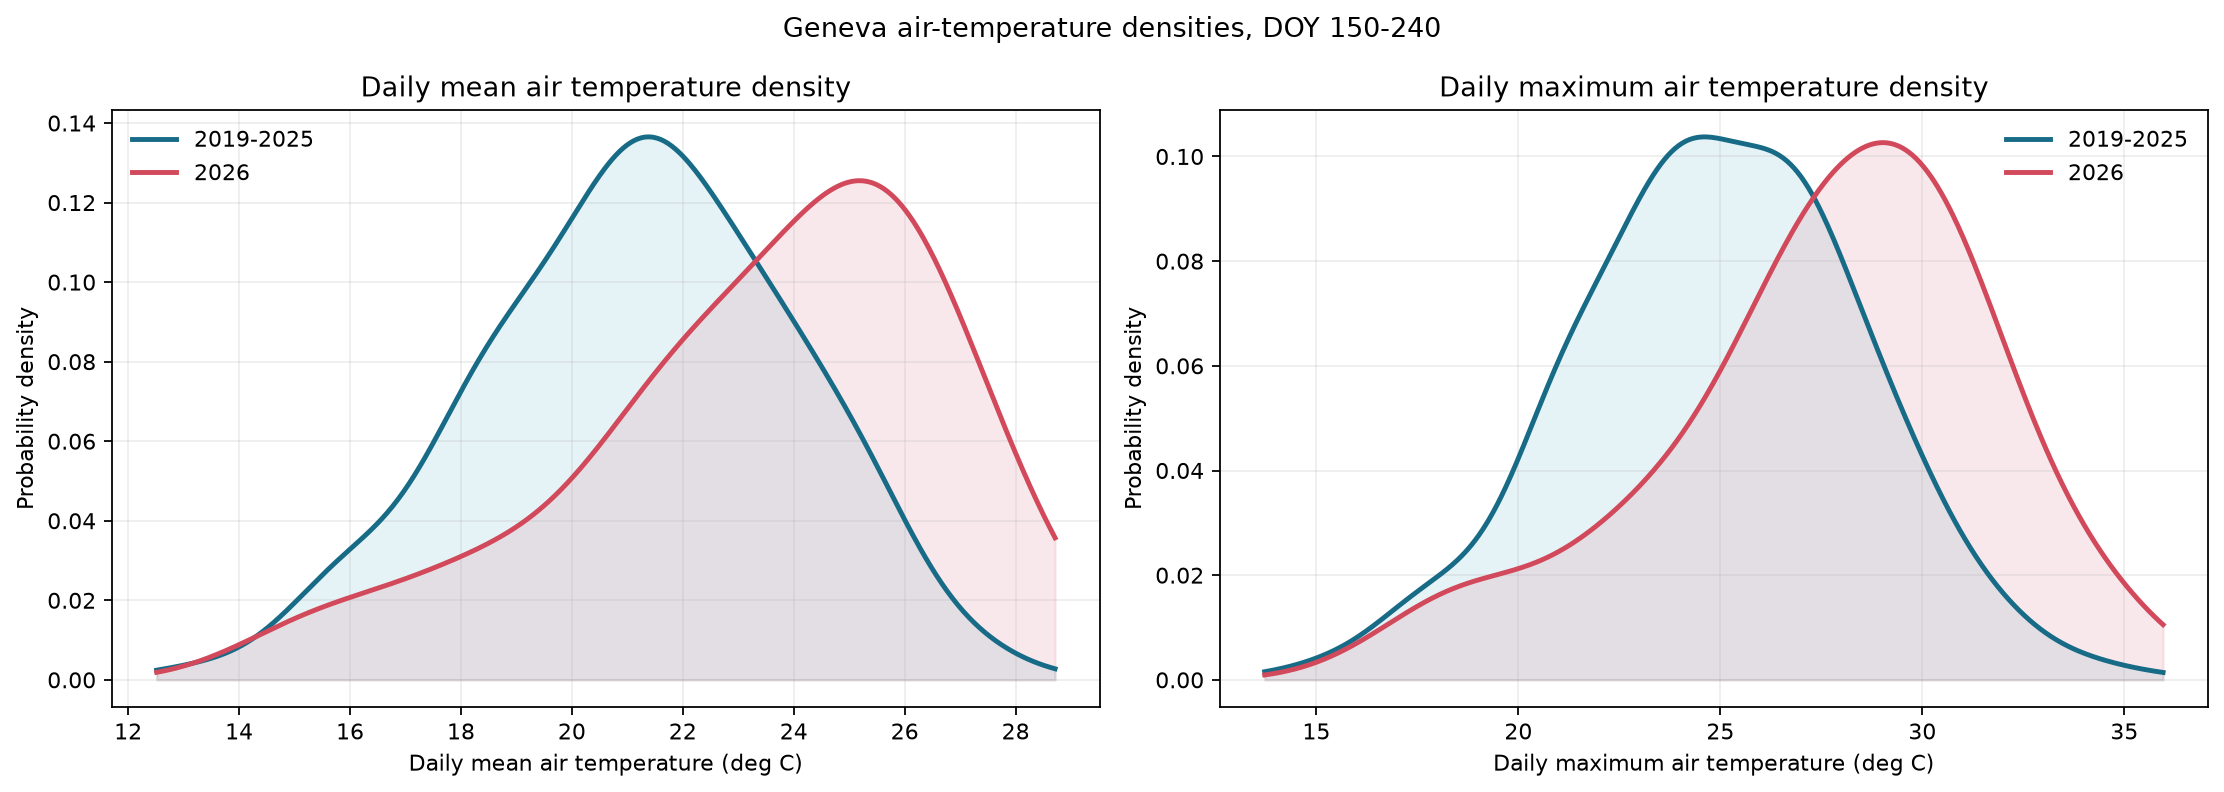

Baseline daily records: 568
2026 daily records: 84


In [5]:
seasonal_daily = daily[daily["day_of_year"].between(DOY_START, DOY_END)]

def gaussian_density(values, grid):
    bandwidth = max(1.06 * values.std(ddof=1) * len(values) ** (-1 / 5), 1e-3)
    kernels = np.exp(-0.5 * ((grid[:, None] - values[None, :]) / bandwidth) ** 2)
    return kernels.mean(axis=1) / (bandwidth * np.sqrt(2 * np.pi))

mean_baseline = seasonal_daily.loc[seasonal_daily["year"].between(2019, 2025), "daily_mean"].to_numpy()
mean_2026 = seasonal_daily.loc[seasonal_daily["year"] == 2026, "daily_mean"].to_numpy()
max_baseline = seasonal_daily.loc[seasonal_daily["year"].between(2019, 2025), "daily_max"].to_numpy()
max_2026 = seasonal_daily.loc[seasonal_daily["year"] == 2026, "daily_max"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=160)
for axis, baseline, comparison, title, xlabel in [
    (axes[0], mean_baseline, mean_2026, "Daily mean air temperature density", "Daily mean air temperature (deg C)"),
    (axes[1], max_baseline, max_2026, "Daily maximum air temperature density", "Daily maximum air temperature (deg C)"),
]:
    values = np.concatenate([baseline, comparison])
    grid = np.linspace(values.min(), values.max(), 500)
    baseline_density = gaussian_density(baseline, grid)
    comparison_density = gaussian_density(comparison, grid)
    axis.plot(grid, baseline_density, color="#176b87", linewidth=2.2, label="2019-2025")
    axis.fill_between(grid, baseline_density, color="#8ec9d8", alpha=0.22)
    axis.plot(grid, comparison_density, color="#d1495b", linewidth=2.2, label="2026")
    axis.fill_between(grid, comparison_density, color="#d1495b", alpha=0.12)
    axis.set(title=title, xlabel=xlabel, ylabel="Probability density")
    axis.grid(True, alpha=0.22)
    axis.legend(frameon=False)
fig.suptitle(f"Geneva air-temperature densities, DOY {DOY_START}-{DOY_END}")
fig.tight_layout()
DENSITY_PNG = OUTPUT_DIR / "geneva_air_temperature_density_doy150_240_2019_2026.png"
fig.savefig(DENSITY_PNG, bbox_inches="tight")
plt.show()
print(f"Baseline daily records: {len(mean_baseline):,}")
print(f"2026 daily records: {len(mean_2026):,}")

## 5. Annual Violin Plot

Show the distribution of daily mean air temperature for each year within DOY 150-240. Red lines indicate medians.

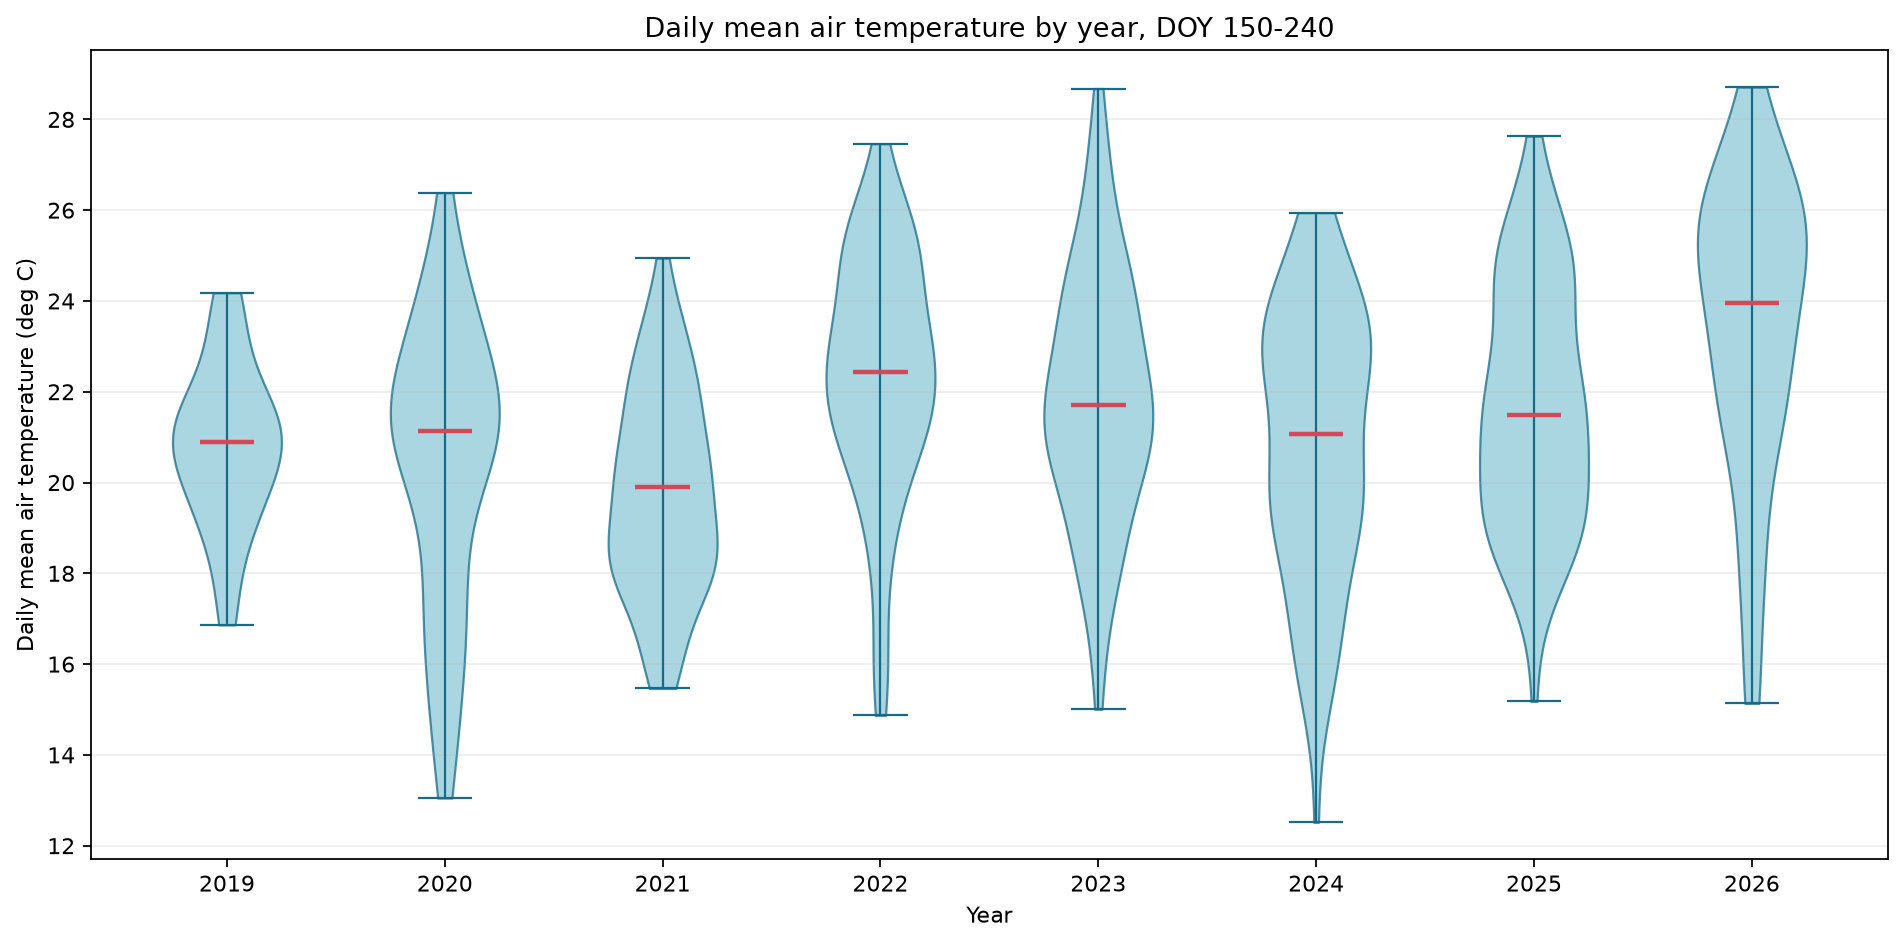

In [6]:
violin_years = sorted(seasonal_daily["year"].unique())
violin_values = [seasonal_daily.loc[seasonal_daily["year"] == year, "daily_mean"].dropna() for year in violin_years]
fig, axis = plt.subplots(figsize=(12, 6), dpi=160)
parts = axis.violinplot(violin_values, positions=np.arange(1, len(violin_years) + 1), showmeans=False, showmedians=True, showextrema=True)
for body in parts["bodies"]:
    body.set_facecolor("#8ec9d8")
    body.set_edgecolor("#176b87")
    body.set_alpha(0.75)
for key in ("cmedians", "cmins", "cmaxes", "cbars"):
    parts[key].set_color("#d1495b" if key == "cmedians" else "#176b87")
    parts[key].set_linewidth(2 if key == "cmedians" else 1)
axis.set_xticks(np.arange(1, len(violin_years) + 1), labels=violin_years)
axis.set(title=f"Daily mean air temperature by year, DOY {DOY_START}-{DOY_END}", xlabel="Year", ylabel="Daily mean air temperature (deg C)")
axis.grid(True, axis="y", alpha=0.22)
fig.tight_layout()
VIOLIN_PNG = OUTPUT_DIR / "geneva_daily_mean_air_temperature_violin_by_year_doy150_240.png"
fig.savefig(VIOLIN_PNG, bbox_inches="tight")
plt.show()

## 6. Top 40 Air-Temperature Days and Outputs

Rank the 40 days with the highest daily mean and daily maximum air temperature across all available years. Also export the daily table and seasonal threshold days above 4 deg C.

In [7]:
ranking_columns = ["timestamp", "year", "day_of_year", "daily_mean", "daily_max", "observations"]
top_40_mean = daily[ranking_columns].sort_values(["daily_mean", "daily_max"], ascending=False).head(40).reset_index(drop=True)
top_40_max = daily[ranking_columns].sort_values(["daily_max", "daily_mean"], ascending=False).head(40).reset_index(drop=True)
top_40_mean.index = top_40_mean.index + 1
top_40_max.index = top_40_max.index + 1
top_40_mean.index.name = "rank"
top_40_max.index.name = "rank"
print("Top 40 days by daily mean air temperature")
display(top_40_mean)
print("Top 40 days by daily maximum air temperature")
display(top_40_max)

temperature_threshold_days = daily.loc[(daily["day_of_year"].between(DOY_START, DOY_END)) & (daily["daily_max"] > TEMPERATURE_THRESHOLD_C), ["timestamp", "daily_max"]].copy()
temperature_threshold_days["date"] = temperature_threshold_days["timestamp"].dt.date
temperature_threshold_days = temperature_threshold_days[["date", "daily_max"]].sort_values("date")

daily.to_csv(OUTPUT_DIR / "geneva_daily_air_temperature_netcdf.csv", index=False)
climatology.to_csv(OUTPUT_DIR / "geneva_air_temperature_climatology_netcdf.csv", index=False)
temperature_threshold_days.to_csv(OUTPUT_DIR / "geneva_days_daily_max_air_temperature_over_4c_doy150_240.csv", index=False)
print(f"NetCDF files: {len(nc_paths):,}")
print(f"Imported DataFrame columns: {len(raw.columns)}")
print(f"Daily records: {len(daily):,}")
print(f"2026 daily records: {len(year_2026):,}")
print(f"DOY {DOY_START}-{DOY_END} days with daily maximum air temperature > {TEMPERATURE_THRESHOLD_C} deg C: {len(temperature_threshold_days):,}")

Top 40 days by daily mean air temperature


,timestamp,year,day_of_year,daily_mean,daily_max,observations
rank,,,,,,
1,2026-07-09 00:00:00+00:00,2026,190,28.711183,32.79,93
2,2023-08-23 00:00:00+00:00,2023,235,28.680000,34.69,143
3,2026-06-23 00:00:00+00:00,2026,174,28.307917,34.73,144
4,2026-06-24 00:00:00+00:00,2026,175,28.180347,34.46,144
5,2026-06-28 00:00:00+00:00,2026,179,27.837431,33.79,144
6,2026-06-22 00:00:00+00:00,2026,173,27.679514,34.84,144
7,2025-08-13 00:00:00+00:00,2025,225,27.630420,35.96,143
8,2023-08-24 00:00:00+00:00,2023,236,27.584126,34.09,143
9,2023-08-22 00:00:00+00:00,2023,234,27.496503,32.64,143


Top 40 days by daily maximum air temperature


,timestamp,year,day_of_year,daily_mean,daily_max,observations
rank,,,,,,
1,2025-08-13 00:00:00+00:00,2025,225,27.630420,35.96,143
2,2026-06-22 00:00:00+00:00,2026,173,27.679514,34.84,144
3,2026-06-23 00:00:00+00:00,2026,174,28.307917,34.73,144
4,2023-08-23 00:00:00+00:00,2023,235,28.680000,34.69,143
5,2026-06-24 00:00:00+00:00,2026,175,28.180347,34.46,144
6,2022-07-18 00:00:00+00:00,2022,199,26.359514,34.25,144
7,2023-08-24 00:00:00+00:00,2023,236,27.584126,34.09,143
8,2026-06-28 00:00:00+00:00,2026,179,27.837431,33.79,144
9,2026-07-12 00:00:00+00:00,2026,193,26.855486,33.45,144


NetCDF files: 371
Imported DataFrame columns: 19
Daily records: 2,539
2026 daily records: 240
DOY 150-240 days with daily maximum air temperature > 4.0 deg C: 652


## 7. Dotplot of the 40 Warmest Days by Daily Mean Air Temperature

Plot the top 40 days ranked by daily mean air temperature. Rank is shown on the x-axis, temperature on the y-axis, and 2026 observations are highlighted in red.

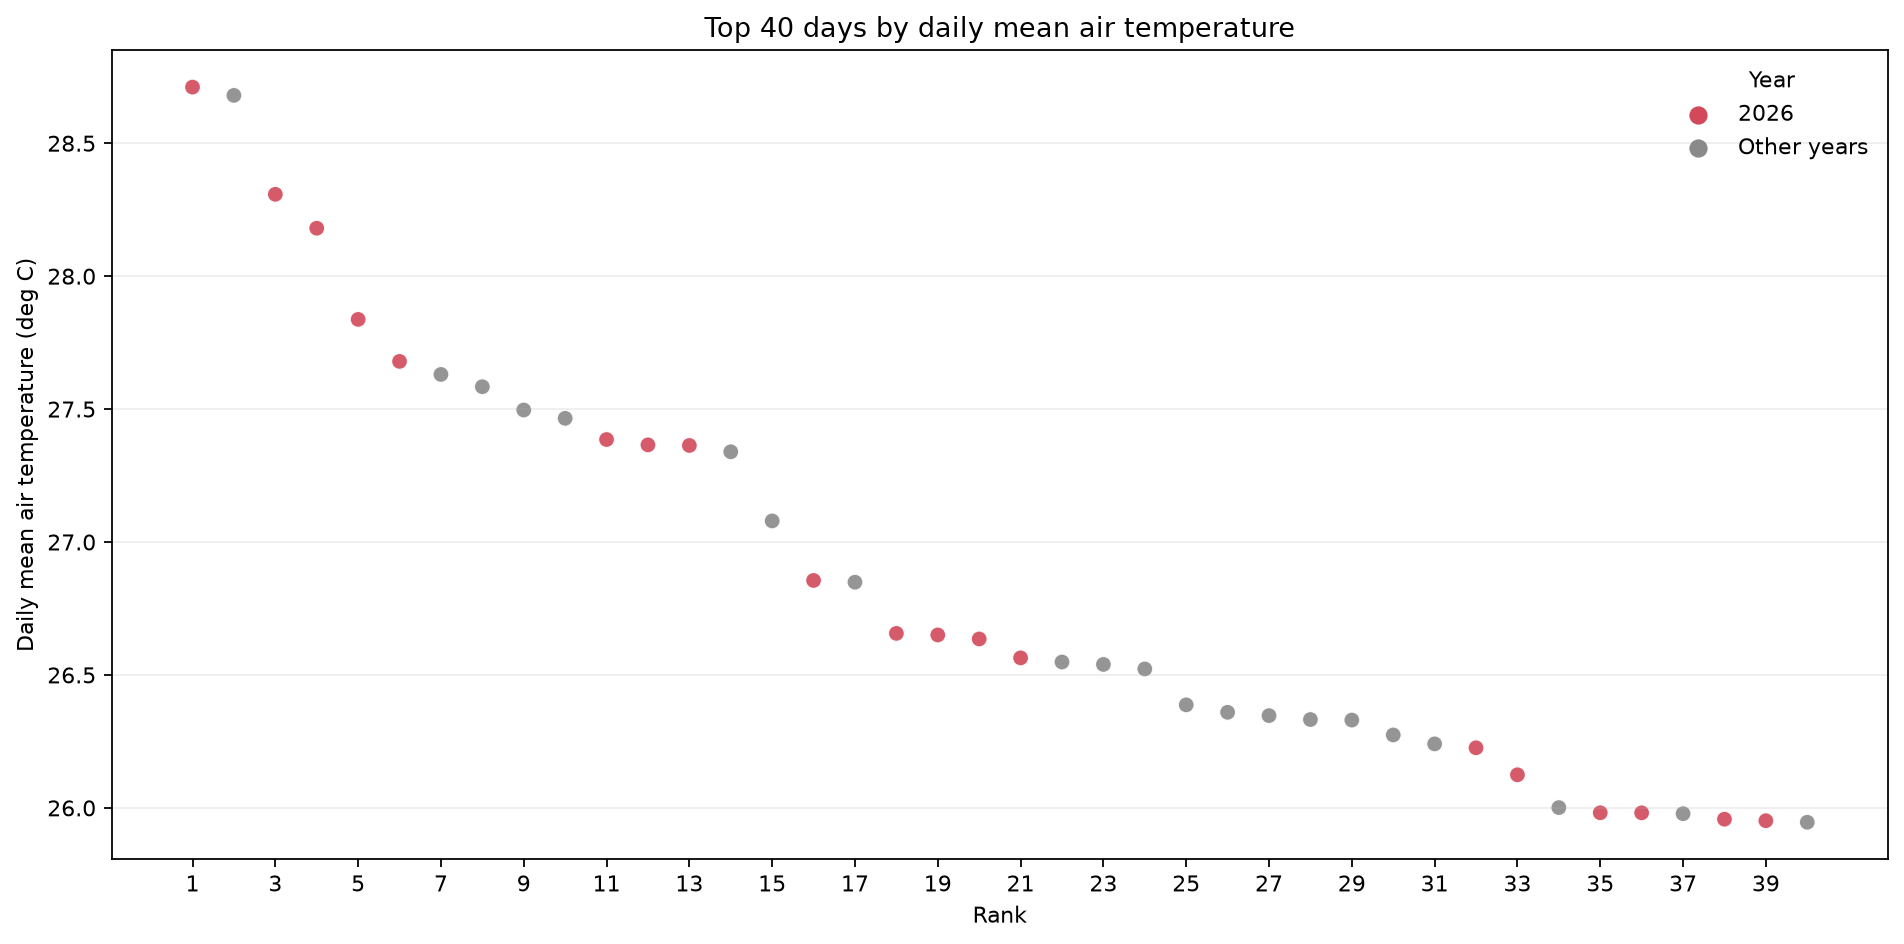

Points plotted: 40
2026 points: 19
Saved: geneva_top40_daily_mean_air_temperature_dotplot.png


In [8]:
# Use the rank index created in the top-40 daily-mean table.
dotplot_data = top_40_mean.copy()
dotplot_data["rank"] = dotplot_data.index

dotplot_colors = np.where(dotplot_data["year"] == 2026, "#d1495b", "#8a8a8a")
figure, axis = plt.subplots(figsize=(12, 6), dpi=160)
axis.scatter(dotplot_data["rank"], dotplot_data["daily_mean"], c=dotplot_colors, s=52, alpha=0.9, edgecolors="white", linewidths=0.6)
axis.scatter([], [], color="#d1495b", s=52, label="2026")
axis.scatter([], [], color="#8a8a8a", s=52, label="Other years")
axis.set_title("Top 40 days by daily mean air temperature")
axis.set_xlabel("Rank")
axis.set_ylabel("Daily mean air temperature (deg C)")
axis.set_xticks(range(1, len(dotplot_data) + 1, 2))
axis.grid(True, axis="y", alpha=0.22)
axis.legend(frameon=False, title="Year")
figure.tight_layout()
DOTPLOT_PNG = OUTPUT_DIR / "geneva_top40_daily_mean_air_temperature_dotplot.png"
figure.savefig(DOTPLOT_PNG, bbox_inches="tight")
plt.show()

print(f"Points plotted: {len(dotplot_data):,}")
print(f"2026 points: {(dotplot_data['year'] == 2026).sum():,}")
print(f"Saved: {DOTPLOT_PNG.name}")

## 8. Dotplot of the 40 Warmest Days by Daily Maximum Air Temperature

Plot the top 40 days ranked by daily maximum air temperature. Rank is shown on the x-axis, temperature on the y-axis, and 2026 observations are highlighted in red.

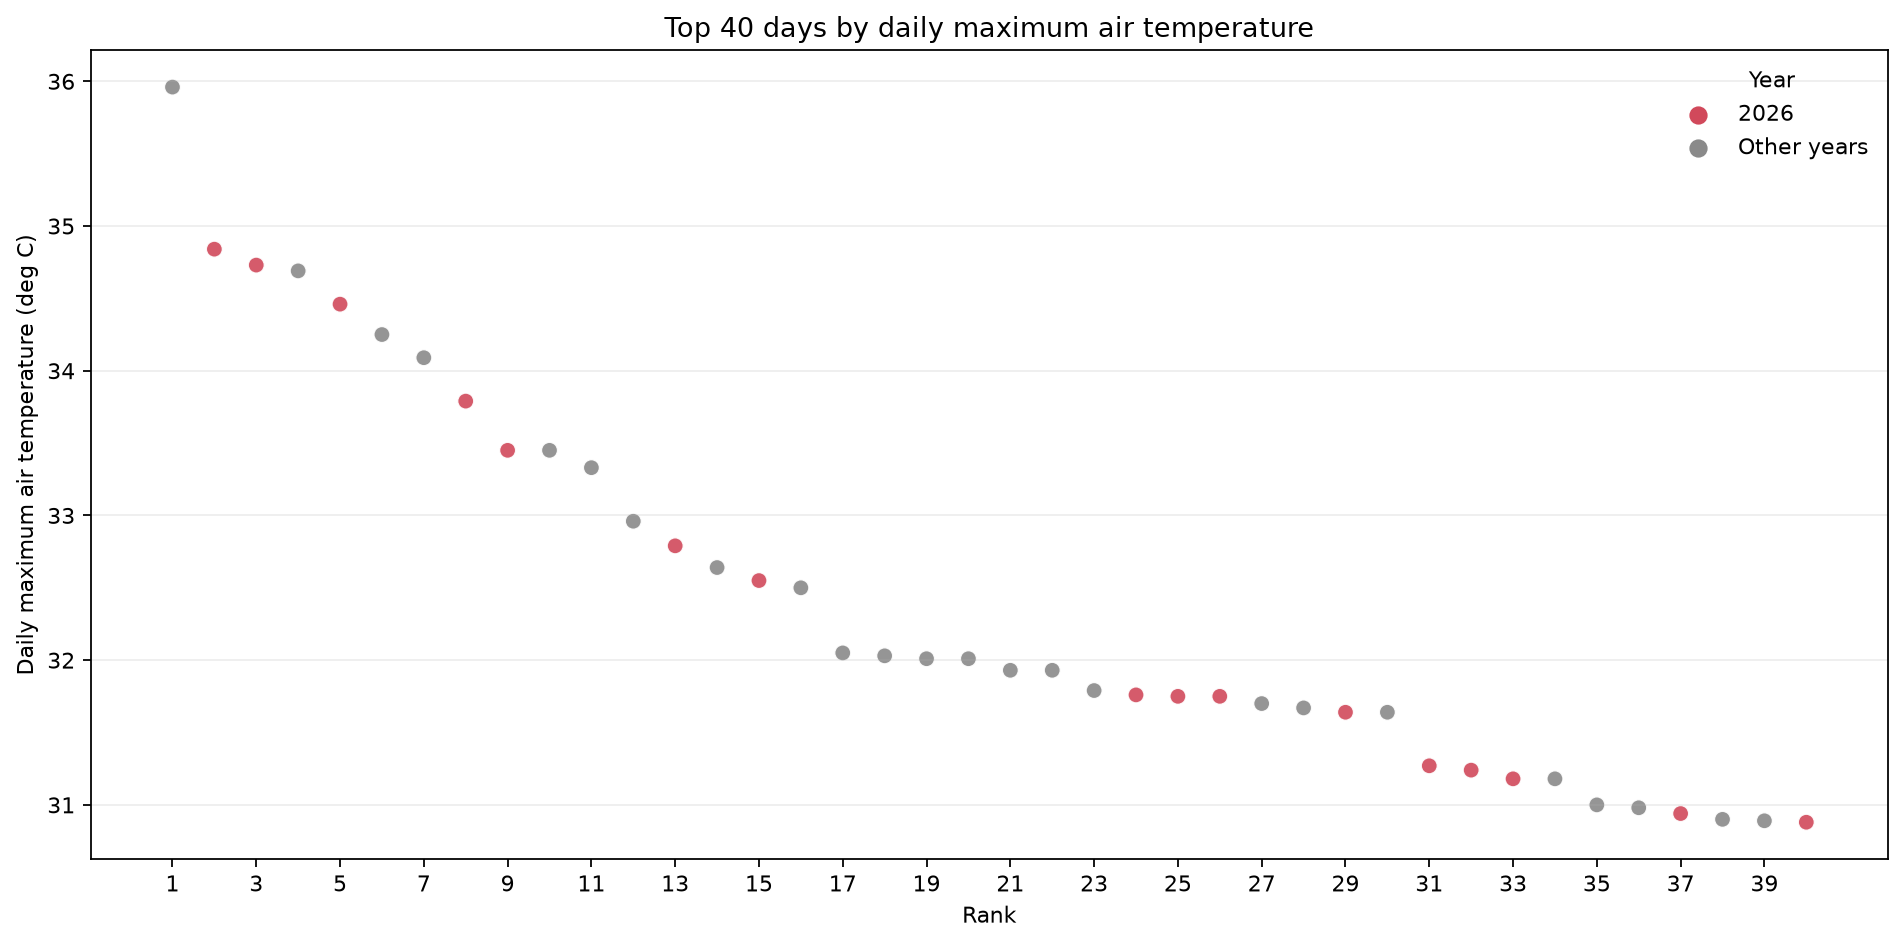

Points plotted: 40
2026 points: 16
Saved: geneva_top40_daily_max_air_temperature_dotplot.png


In [9]:
# Use the rank order from the top-40 daily-maximum table.
max_dotplot_data = top_40_max.copy()
max_dotplot_data["rank"] = max_dotplot_data.index

max_dotplot_colors = np.where(max_dotplot_data["year"] == 2026, "#d1495b", "#8a8a8a")
figure, axis = plt.subplots(figsize=(12, 6), dpi=160)
axis.scatter(max_dotplot_data["rank"], max_dotplot_data["daily_max"], c=max_dotplot_colors, s=52, alpha=0.9, edgecolors="white", linewidths=0.6)
axis.scatter([], [], color="#d1495b", s=52, label="2026")
axis.scatter([], [], color="#8a8a8a", s=52, label="Other years")
axis.set_title("Top 40 days by daily maximum air temperature")
axis.set_xlabel("Rank")
axis.set_ylabel("Daily maximum air temperature (deg C)")
axis.set_xticks(range(1, len(max_dotplot_data) + 1, 2))
axis.grid(True, axis="y", alpha=0.22)
axis.legend(frameon=False, title="Year")
figure.tight_layout()
MAX_DOTPLOT_PNG = OUTPUT_DIR / "geneva_top40_daily_max_air_temperature_dotplot.png"
figure.savefig(MAX_DOTPLOT_PNG, bbox_inches="tight")
plt.show()

print(f"Points plotted: {len(max_dotplot_data):,}")
print(f"2026 points: {(max_dotplot_data['year'] == 2026).sum():,}")
print(f"Saved: {MAX_DOTPLOT_PNG.name}")